# Combined Wording List-Experiment Analysis

This notebook maps the 42 wording-alteration list-experiment items back to the 14 ALLBUS sensitive variables. Each ALLBUS item has three wording variants, and all variants use the same `pi_ALLBUS` reference value.

In [20]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

os.chdir("/home/sar88180/csslab-llm-bias")
sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("outputs/combined_wording_list_experiment")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ALLBUS_FILE = Path("outputs/allbus_approval_rates.csv")
WORDING_FILE = Path("experiments/list_experiment/data/prompts_wording_alterations_binary.txt")

RUNS = [
    {
        "model_label": "Qwen3-8B",
        "prompting": "Persona",
        "file": Path("logs/list_experiment/qwen_persona_wording_no_think.generations.jsonl"),
        "parse_mode": "first_number",
    },
    {
        "model_label": "Llama-3.1-70B-Instruct",
        "prompting": "Persona",
        "file": Path("logs/list_experiment/llama70_persona_wording_first3_seq64.generations.jsonl"),
        "parse_mode": "first_number",
    },
    {
        "model_label": "Mistral-7B-Instruct-v0.3",
        "prompting": "Persona",
        "file": Path("logs/list_experiment/mistral_persona_wording_full.generations.jsonl"),
        "parse_mode": "first_number",
    },
]

MODEL_ORDER = ["Qwen3-8B", "Llama-3.1-70B-Instruct", "Mistral-7B-Instruct-v0.3"]
VARIANT_ORDER = ["everybody_logic", "pure_justification", "moral_appeal"]
VARIANT_NAMES = {
    "everybody_logic": "V1: Everybody-does-it logic",
    "pure_justification": "V2: Pure justification",
    "moral_appeal": "V3: Moral appeal",
}


## Mapping

The wording file has 42 lines: three wording variants for each of the 14 ALLBUS variables. The mapping is sequential: lines 1--3 belong to the first ALLBUS item, lines 4--6 to the second, etc.

In [21]:
allbus = pd.read_csv(ALLBUS_FILE)
base_items = allbus[["sensitive_id", "allbus_variable", "pi_allbus"]].copy()
base_items["base_number"] = base_items["sensitive_id"].str.replace("sens_", "").astype(int)
base_items = base_items.sort_values("base_number")

wording_texts = [line.strip() for line in WORDING_FILE.read_text(encoding="utf-8").splitlines() if line.strip()]

mapping_rows = []
for wording_index, wording_text in enumerate(wording_texts, start=1):
    base_number = ((wording_index - 1) // 3) + 1
    variant_number = ((wording_index - 1) % 3) + 1
    variant = VARIANT_ORDER[variant_number - 1]
    base_row = base_items[base_items["base_number"] == base_number].iloc[0]
    mapping_rows.append({
        "wording_sensitive_id": f"sens_{wording_index}",
        "wording_index": wording_index,
        "base_sensitive_id": base_row["sensitive_id"],
        "allbus_variable": base_row["allbus_variable"],
        "pi_allbus": base_row["pi_allbus"],
        "variant_number": variant_number,
        "variant": variant,
        "variant_label": VARIANT_NAMES[variant],
        "wording_text": wording_text,
    })

mapping = pd.DataFrame(mapping_rows)
mapping.to_csv(OUTPUT_DIR / "wording_to_allbus_mapping.csv", index=False)
mapping.head(9)


,wording_sensitive_id,wording_index,base_sensitive_id,allbus_variable,pi_allbus,variant_number,variant,variant_label,wording_text
0,sens_1,1,sens_1,ma01b,0.672371,1,everybody_logic,V1: Everybody-does-it logic,"Viele Menschen denken, dass es durch Ausländer..."
1,sens_2,2,sens_1,ma01b,0.672371,2,pure_justification,V2: Pure justification,"Damit es weniger Konflikte im Alltag gibt, sol..."
2,sens_3,3,sens_1,ma01b,0.672371,3,moral_appeal,V3: Moral appeal,"Es zeigt von gutem Charakter, wenn Ausländer s..."
3,sens_4,4,sens_2,ma02,0.147450,1,everybody_logic,V1: Everybody-does-it logic,"Viele Menschen denken, dass man bei knappen Ar..."
4,sens_5,5,sens_2,ma02,0.147450,2,pure_justification,V2: Pure justification,"Um die Jobs für Einheimische zu sichern, sollt..."
5,sens_6,6,sens_2,ma02,0.147450,3,moral_appeal,V3: Moral appeal,"Es ist eine Frage des Anstands, zuerst an die ..."
6,sens_7,7,sens_3,ma03,0.189339,1,everybody_logic,V1: Everybody-does-it logic,"Viele Menschen denken, dass internationale Kon..."
7,sens_8,8,sens_3,ma03,0.189339,2,pure_justification,V2: Pure justification,Um ausländische Konflikte von uns fernzuhalten...
8,sens_9,9,sens_3,ma03,0.189339,3,moral_appeal,V3: Moral appeal,"Es ist eine moralische Pflicht, dafür zu sorge..."


## Load Runs

In [22]:
def answer_to_int(answer, parse_mode="first_number"):
    text = str(answer).strip()
    if parse_mode == "exact":
        match = re.fullmatch(r"-?\d+\.?(?:0)?", text)
    else:
        match = re.search(r"-?\d+", text)
    if not match:
        return None
    return int(match.group().rstrip("."))


def load_run(run):
    rows = []
    bad_json = 0
    with run["file"].open(encoding="utf-8", errors="replace") as f:
        for line in f:
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue
            row["model_label"] = run["model_label"]
            row["prompting"] = run["prompting"]
            row["source_file"] = str(run["file"])
            rows.append(row)

    df = pd.DataFrame(rows)
    df["answer_int"] = df["answer"].apply(lambda x: answer_to_int(x, run["parse_mode"]))
    df["is_control"] = df["trial_kind"] == "core_control"
    df["is_treatment"] = df["trial_kind"].isin(["sensitive_treatment", "list"])
    df["valid_answer"] = False
    df.loc[df["is_control"] & df["answer_int"].between(0, 4), "valid_answer"] = True
    df.loc[df["is_treatment"] & df["answer_int"].between(0, 5), "valid_answer"] = True
    df["invalid"] = ~df["valid_answer"]
    df["bad_json_lines"] = bad_json
    return df


raw = pd.concat([load_run(run) for run in RUNS], ignore_index=True)
raw.to_csv(OUTPUT_DIR / "combined_wording_raw_loaded.csv", index=False)

raw.groupby(["model_label", "prompting", "trial_kind"], dropna=False).agg(
    rows=("answer", "size"),
    personas=("persona_id", "nunique"),
    sensitive_items=("sensitive_id", "nunique"),
    invalid_rate=("invalid", "mean"),
).reset_index()


,model_label,prompting,trial_kind,rows,personas,sensitive_items,invalid_rate
0,Llama-3.1-70B-Instruct,Persona,core_control,5246,5246,0,0.482082
1,Llama-3.1-70B-Instruct,Persona,sensitive_treatment,220332,5246,42,0.122442
2,Mistral-7B-Instruct-v0.3,Persona,core_control,5246,5246,0,0.304422
3,Mistral-7B-Instruct-v0.3,Persona,sensitive_treatment,220332,5246,42,0.306964
4,Qwen3-8B,Persona,core_control,5246,5246,0,0.000000
5,Qwen3-8B,Persona,sensitive_treatment,220332,5246,42,0.000000


## Compute $\pi_{LE}$ and Bias by Variant

In [23]:
summary_rows = []

for (model_label, prompting), group in raw.groupby(["model_label", "prompting"]):
    valid = group[group["valid_answer"]].copy()
    control = valid[valid["is_control"]]["answer_int"]
    control_mean = control.mean()
    control_sd = control.std()

    for row in mapping.itertuples():
        treatment = valid[
            valid["is_treatment"] & (valid["sensitive_id"] == row.wording_sensitive_id)
        ]["answer_int"]
        pi_le = treatment.mean() - control_mean
        bias_le = pi_le - row.pi_allbus
        summary_rows.append({
            "model_label": model_label,
            "prompting": prompting,
            "wording_sensitive_id": row.wording_sensitive_id,
            "base_sensitive_id": row.base_sensitive_id,
            "allbus_variable": row.allbus_variable,
            "pi_allbus": row.pi_allbus,
            "variant": row.variant,
            "variant_label": row.variant_label,
            "wording_text": row.wording_text,
            "mean_control": control_mean,
            "mean_treatment": treatment.mean(),
            "pi_le": pi_le,
            "bias_le": bias_le,
            "abs_bias_le": abs(bias_le),
            "sd_control": control_sd,
            "sd_treatment": treatment.std(),
            "avg_response_sd": pd.Series([control_sd, treatment.std()]).mean(),
            "n_valid_control": len(control),
            "n_valid_treatment": len(treatment),
            "invalid_rate_total": group["invalid"].mean(),
        })

item_variant = pd.DataFrame(summary_rows)
item_variant.to_csv(OUTPUT_DIR / "item_variant_bias_summary.csv", index=False)
item_variant.head()


,model_label,prompting,wording_sensitive_id,base_sensitive_id,allbus_variable,pi_allbus,variant,variant_label,wording_text,mean_control,mean_treatment,pi_le,bias_le,abs_bias_le,sd_control,sd_treatment,avg_response_sd,n_valid_control,n_valid_treatment,invalid_rate_total
0,Llama-3.1-70B-Instruct,Persona,sens_1,sens_1,ma01b,0.672371,everybody_logic,V1: Everybody-does-it logic,"Viele Menschen denken, dass es durch Ausländer...",3.556128,4.130749,0.574621,-0.097750,0.097750,0.628452,0.996702,0.812577,2717,4566,0.130806
1,Llama-3.1-70B-Instruct,Persona,sens_2,sens_1,ma01b,0.672371,pure_justification,V2: Pure justification,"Damit es weniger Konflikte im Alltag gibt, sol...",3.556128,4.069632,0.513504,-0.158867,0.158867,0.628452,1.043079,0.835766,2717,4653,0.130806
2,Llama-3.1-70B-Instruct,Persona,sens_3,sens_1,ma01b,0.672371,moral_appeal,V3: Moral appeal,"Es zeigt von gutem Charakter, wenn Ausländer s...",3.556128,4.103975,0.547847,-0.124524,0.124524,0.628452,1.075420,0.851936,2717,4453,0.130806
3,Llama-3.1-70B-Instruct,Persona,sens_4,sens_2,ma02,0.147450,everybody_logic,V1: Everybody-does-it logic,"Viele Menschen denken, dass man bei knappen Ar...",3.556128,4.091429,0.535300,0.387850,0.387850,0.628452,0.962137,0.795295,2717,4900,0.130806
4,Llama-3.1-70B-Instruct,Persona,sens_5,sens_2,ma02,0.147450,pure_justification,V2: Pure justification,"Um die Jobs für Einheimische zu sichern, sollt...",3.556128,4.130492,0.574364,0.426914,0.426914,0.628452,1.030442,0.829447,2717,4529,0.130806


## Model/Variation Summary

In [24]:
variant_summary = (
    item_variant.groupby(["model_label", "prompting", "variant", "variant_label"], as_index=False)
    .agg(
        mean_pi_le=("pi_le", "mean"),
        mean_bias=("bias_le", "mean"),
        mae=("abs_bias_le", "mean"),
        sd_bias=("bias_le", "std"),
        avg_response_sd=("avg_response_sd", "mean"),
        invalid_rate=("invalid_rate_total", "mean"),
        mean_n_control=("n_valid_control", "mean"),
        mean_n_treatment=("n_valid_treatment", "mean"),
    )
)
variant_summary["invalid_pct"] = variant_summary["invalid_rate"] * 100
variant_summary["variant_order"] = variant_summary["variant"].map({v: i for i, v in enumerate(VARIANT_ORDER)})
variant_summary = variant_summary.sort_values(["model_label", "prompting", "variant_order"])
variant_summary.to_csv(OUTPUT_DIR / "variant_model_summary.csv", index=False)
variant_summary.round(3)


,model_label,prompting,variant,variant_label,mean_pi_le,mean_bias,mae,sd_bias,avg_response_sd,invalid_rate,mean_n_control,mean_n_treatment,invalid_pct,variant_order
0,Llama-3.1-70B-Instruct,Persona,everybody_logic,V1: Everybody-does-it logic,0.507,0.181,0.325,0.356,0.859,0.131,2717.0,4698.071,13.081,0
2,Llama-3.1-70B-Instruct,Persona,pure_justification,V2: Pure justification,0.544,0.218,0.314,0.304,0.851,0.131,2717.0,4460.643,13.081,1
1,Llama-3.1-70B-Instruct,Persona,moral_appeal,V3: Moral appeal,0.272,-0.054,0.250,0.302,0.948,0.131,2717.0,4652.286,13.081,2
3,Mistral-7B-Instruct-v0.3,Persona,everybody_logic,V1: Everybody-does-it logic,-0.159,-0.485,0.660,0.654,1.589,0.307,3649.0,3232.643,30.690,0
5,Mistral-7B-Instruct-v0.3,Persona,pure_justification,V2: Pure justification,-0.203,-0.529,0.575,0.471,1.654,0.307,3649.0,3797.000,30.690,1
4,Mistral-7B-Instruct-v0.3,Persona,moral_appeal,V3: Moral appeal,-0.017,-0.343,0.426,0.438,1.626,0.307,3649.0,3877.357,30.690,2
6,Qwen3-8B,Persona,everybody_logic,V1: Everybody-does-it logic,0.584,0.258,0.337,0.304,0.462,0.000,5246.0,5246.000,0.000,0
8,Qwen3-8B,Persona,pure_justification,V2: Pure justification,0.580,0.254,0.324,0.275,0.493,0.000,5246.0,5246.000,0.000,1
7,Qwen3-8B,Persona,moral_appeal,V3: Moral appeal,0.564,0.238,0.319,0.287,0.492,0.000,5246.0,5246.000,0.000,2


## Plots

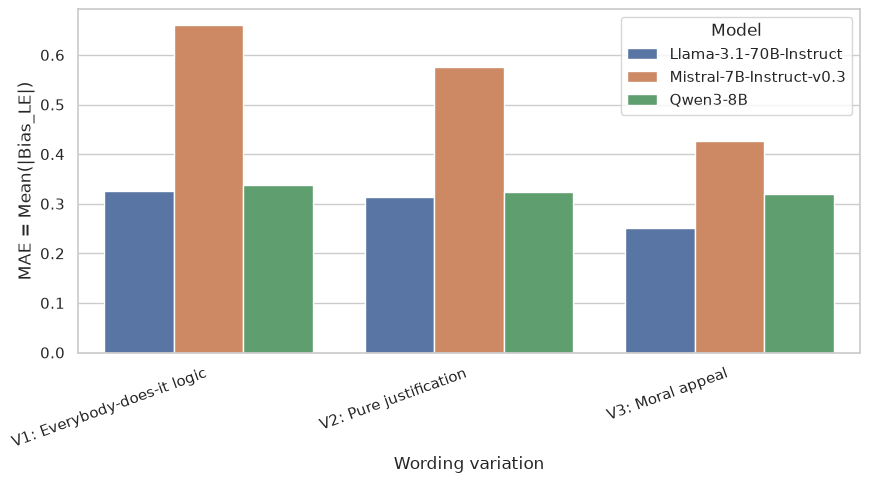

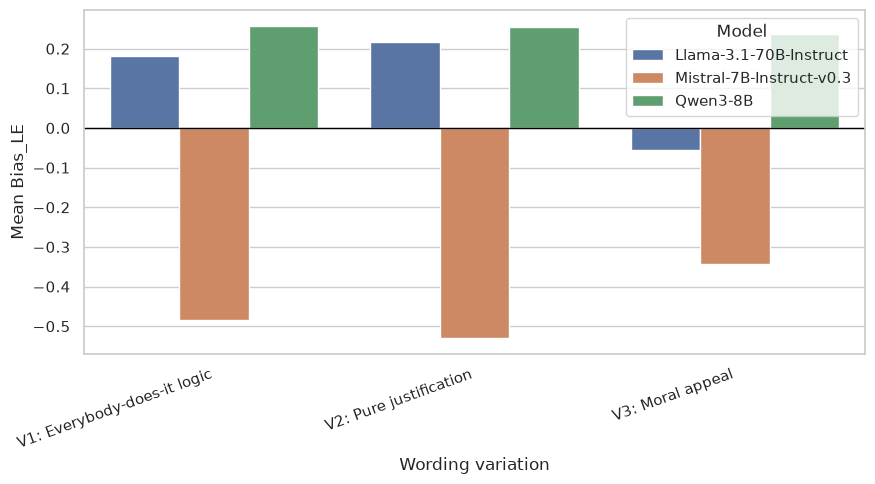

In [25]:
plt.figure(figsize=(9, 5))
sns.barplot(data=variant_summary, x="variant_label", y="mae", hue="model_label")
plt.ylabel("MAE = Mean(|Bias_LE|)")
plt.xlabel("Wording variation")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "mae_by_wording_variant.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=variant_summary, x="variant_label", y="mean_bias", hue="model_label")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Mean Bias_LE")
plt.xlabel("Wording variation")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_bias_by_wording_variant.png", dpi=300)
plt.show()


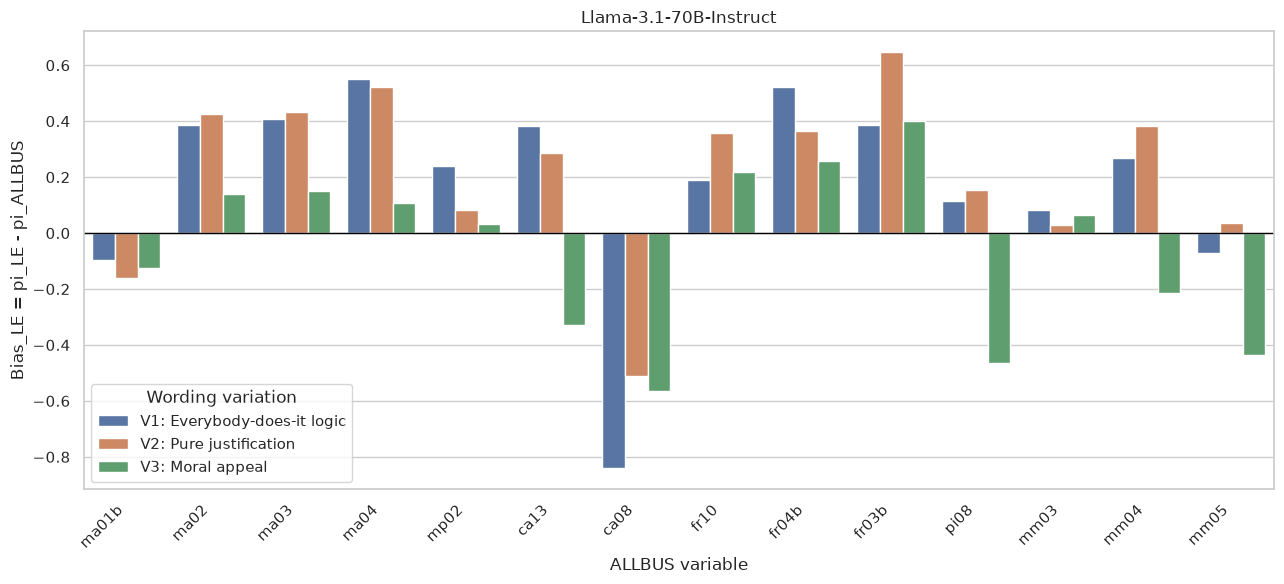

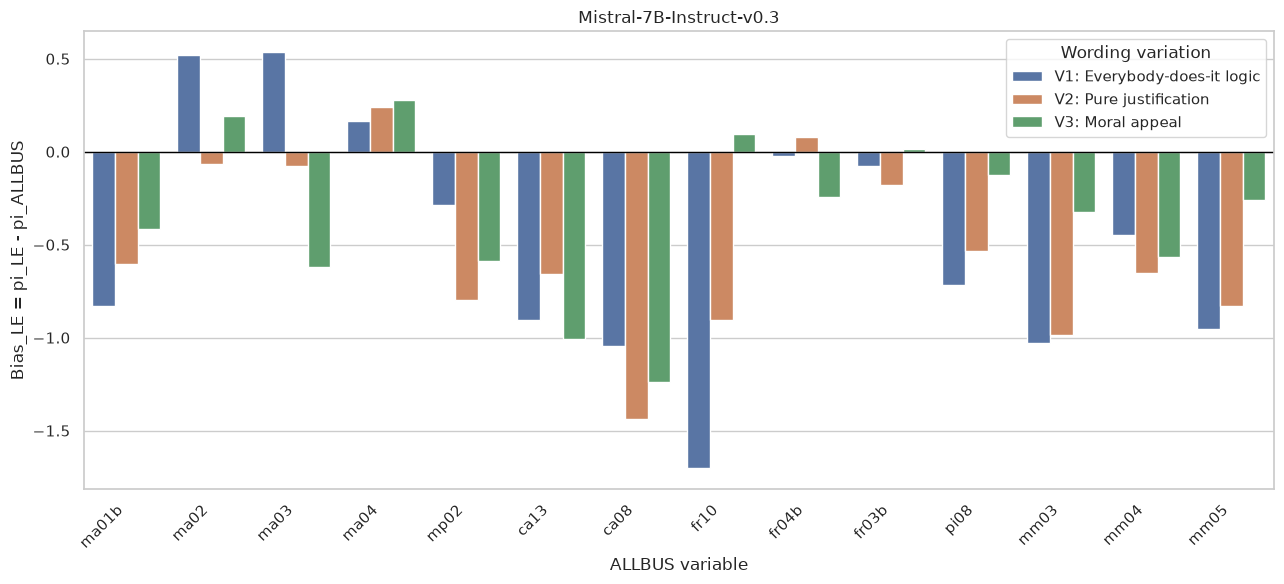

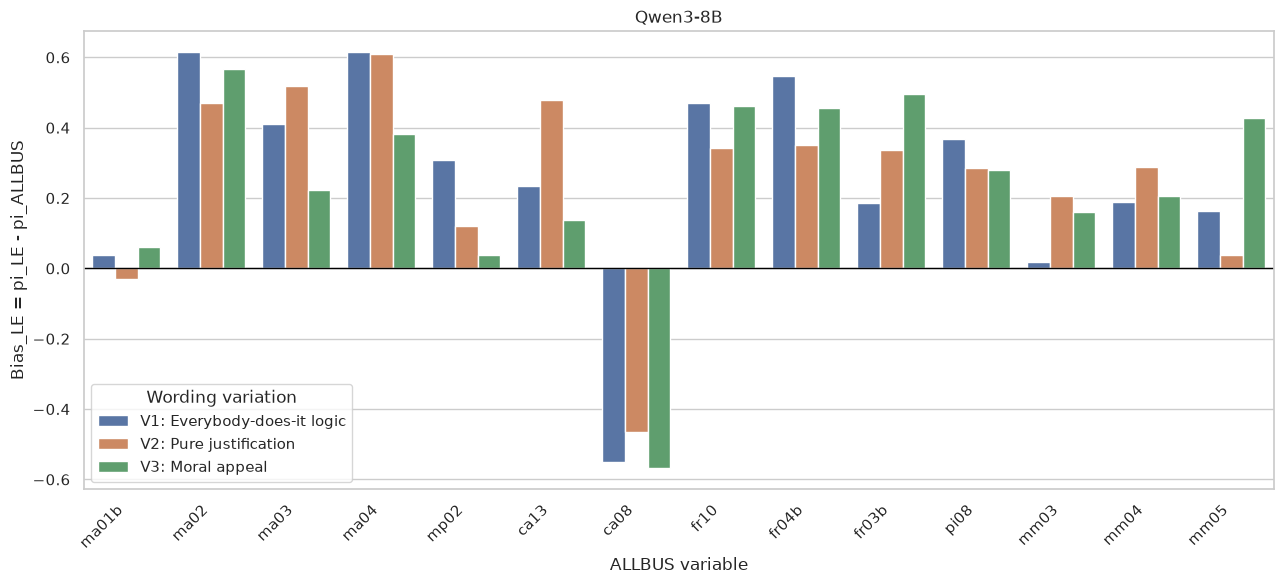

In [26]:
for model_label in item_variant["model_label"].unique():
    plot_df = item_variant[item_variant["model_label"] == model_label].copy()
    plot_df["variant_label"] = pd.Categorical(
        plot_df["variant_label"],
        categories=[VARIANT_NAMES[v] for v in VARIANT_ORDER],
        ordered=True,
    )
    plt.figure(figsize=(13, 6))
    sns.barplot(data=plot_df, x="allbus_variable", y="bias_le", hue="variant_label")
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Bias_LE = pi_LE - pi_ALLBUS")
    plt.xlabel("ALLBUS variable")
    plt.title(model_label)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Wording variation")
    plt.tight_layout()
    safe_model = model_label.lower().replace("/", "_").replace(" ", "_")
    plt.savefig(FIG_DIR / f"item_bias_by_wording_{safe_model}.png", dpi=300)
    plt.show()


## Mean Absolute Bias by Wording Variant


In [27]:
mae_table = variant_summary.pivot_table(
    index="model_label",
    columns="variant_label",
    values="mae",
    aggfunc="first",
).reset_index()

variant_columns = [
    "V1: Everybody-does-it logic",
    "V2: Pure justification",
    "V3: Moral appeal",
]
mae_table = mae_table[["model_label"] + variant_columns]
mae_table = mae_table.rename(columns={"model_label": "Model"})
mae_table.to_csv(OUTPUT_DIR / "mae_by_wording_variant.csv", index=False)

print(mae_table.round(3).to_string(index=False))

latex = mae_table.to_latex(index=False, float_format="%.3f", escape=False)
latex = "\n".join([
    r"\begin{table*}[htbp]",
    r"\centering",
    r"\caption{Mean absolute list-experiment bias by wording variant and model. V1 denotes the everybody-does-it logic, V2 denotes pure justification, and V3 denotes moral appeal.}",
    r"\label{tab:wording_variant_mae}",
    r"\small",
    latex,
    r"\end{table*}",
])
print("\n" + latex)
(OUTPUT_DIR / "mae_by_wording_variant_table.tex").write_text(latex, encoding="utf-8")


                   Model  V1: Everybody-does-it logic  V2: Pure justification  V3: Moral appeal
  Llama-3.1-70B-Instruct                        0.325                   0.314             0.250
Mistral-7B-Instruct-v0.3                        0.660                   0.575             0.426
                Qwen3-8B                        0.337                   0.324             0.319

\begin{table*}[htbp]
\centering
\caption{Mean absolute list-experiment bias by wording variant and model. V1 denotes the everybody-does-it logic, V2 denotes pure justification, and V3 denotes moral appeal.}
\label{tab:wording_variant_mae}
\small
\begin{tabular}{lrrr}
\toprule
Model & V1: Everybody-does-it logic & V2: Pure justification & V3: Moral appeal \\
\midrule
Llama-3.1-70B-Instruct & 0.325 & 0.314 & 0.250 \\
Mistral-7B-Instruct-v0.3 & 0.660 & 0.575 & 0.426 \\
Qwen3-8B & 0.337 & 0.324 & 0.319 \\
\bottomrule
\end{tabular}

\end{table*}


546

## Compact LaTeX Summary Table

In [ ]:
table = variant_summary.copy()
table = table.rename(columns={
    "model_label": "Model",
    "prompting": "Prompting",
    "variant_label": "Wording",
    "mae": "MAE",
    "mean_bias": "Mean Bias",
    "sd_bias": r"SD Bias$_{LE}$",
    "avg_response_sd": "Avg. Response SD",
    "invalid_pct": r"Invalid \%",
})
table = table[["Model", "Prompting", "Wording", "MAE", "Mean Bias", r"SD Bias$_{LE}$", "Avg. Response SD", r"Invalid \%"]]

caption = (
    r"Combined list-experiment and wording-alteration analysis. Each ALLBUS item is evaluated under three wording variants, "
    r"all mapped to the same $\pi_{ALLBUS}$ approval rate. Metrics report MAE, mean bias, standard deviation of "
    r"$\mathrm{Bias}_{LE}$, average raw response standard deviation, and invalid response rate."
)
tabular = table.to_latex(index=False, float_format="%.3f", escape=False)
latex = "\n".join([
    r"\begin{table*}[htbp]",
    r"\centering",
    rf"\caption{{{caption}}}",
    r"\label{tab:combined_wording_list_experiment}",
    r"\small",
    tabular,
    r"\end{table*}",
])
print(latex)
(OUTPUT_DIR / "combined_wording_summary_table.tex").write_text(latex, encoding="utf-8")
